# ABI Baseline vs Cost-Weighted GEC — Holdout Evaluation & Comparison

Loads a selected ABI checkpoint (from `checkpoints_abi_whole_brain/`) and a selected
GEC checkpoint (from `checkpoints_cost_weighted_gec_whole_brain/`), then evaluates both
on the held-out test set using their respective CV-derived thresholds.

**Prerequisites**:
- Run `ABI_BASELINE.ipynb` to generate an ABI checkpoint
- Run `COST_WEIGHTED_GEC_DELCODE_WHOLE_BRAIN.ipynb` (including the holdout evaluation cell) to generate GEC holdout predictions

In [12]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import sys
import tempfile
import warnings

from pathlib import Path
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
from datetime import datetime

import torch
from torch_geometric.loader import DataLoader

model_root = Path('/mnt/e/fyassine/ad-early-detection/MODEL')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(model_root))

from model.CostWeightedGEC.dataset import ClassificationDataset, CombinedClassificationDataset
from model.CostWeightedGEC.models import GraphEncoderClassifierAttention
from model.CostWeightedGEC.utils import knn_binary_adjacency_matrix_no_diag

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore', category=FutureWarning)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Configuration & Checkpoint Selection

Select an ABI run and a GEC run from their respective checkpoint directories.

In [13]:
ABI_CHECKPOINT_DIR = Path('/mnt/e/fyassine/ad-early-detection/DCI/notebooks/checkpoints_abi_whole_brain')
GEC_CHECKPOINT_DIR = Path('/mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_cost_weighted_gec_whole_brain')
METADATA_DIR = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata')
COHORTS_CSV = METADATA_DIR / 'cohorts.csv'
OUTPUT_DIR = Path('/mnt/e/fyassine/ad-early-detection/DCI/notebooks/artifacts')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS = 5
RANDOM_STATE = 42

def select_checkpoint(checkpoint_dir, label, summary_filename='run_summary.json'):
    candidates = sorted([
        d for d in checkpoint_dir.iterdir()
        if d.is_dir() and (d / summary_filename).exists()
    ], key=lambda d: d.name)
    if not candidates:
        raise FileNotFoundError(f'No {label} checkpoints found in {checkpoint_dir}')
    print(f'Available {label} checkpoints:')
    for i, d in enumerate(candidates):
        print(f'  {i}: {d.name}')
    default_idx = len(candidates) - 1
    sel = input(f'Select {label} checkpoint [default {default_idx}]: ').strip()
    idx = default_idx if sel == '' else int(sel)
    if idx < 0 or idx >= len(candidates):
        raise IndexError(f'{label} checkpoint index out of range: {idx}')
    selected = candidates[idx]
    with open(selected / summary_filename, 'r') as f:
        summary = json.load(f)
    print(f'Selected: {selected.name}')
    return selected, summary

abi_run_dir, abi_summary = select_checkpoint(ABI_CHECKPOINT_DIR, 'ABI')
print()
gec_run_dir, gec_summary = select_checkpoint(GEC_CHECKPOINT_DIR, 'GEC')

Available ABI checkpoints:
  0: abi_run_2026-04-20_18-25-17
  1: abi_run_2026-04-21_17-45-26
Selected: abi_run_2026-04-21_17-45-26

Available GEC checkpoints:
  0: cv_run_2026-04-20_16-13-00
  1: cv_run_2026-04-20_16-29-28
  2: cv_run_2026-04-21_17-24-51
  3: cv_run_2026-04-21_17-44-35
Selected: cv_run_2026-04-21_17-44-35


## Load ABI and GEC Results from Selected Checkpoints

In [14]:
abi_values_path = abi_run_dir / 'abi_values.csv'
if not abi_values_path.exists():
    raise FileNotFoundError(f'Missing abi_values.csv in {abi_run_dir}')

abi_values_df = pd.read_csv(abi_values_path)
abi_values_df['subject_id'] = abi_values_df['subject_id'].astype(str)
abi_values_df['diagnosis'] = abi_values_df['diagnosis'].astype(str).str.lower().str.strip()

abi_cv_results = abi_summary['cv_results']
abi_cv_summary = abi_summary['cv_summary']
abi_best_threshold = float(abi_summary['best_threshold'])

cv_df = abi_values_df[abi_values_df['split'].isin(['train', 'val'])].reset_index(drop=True)
holdout_df = abi_values_df[abi_values_df['split'] == 'test'].reset_index(drop=True)

cv_subjects = int(cv_df['subject_id'].nunique())
holdout_subjects = int(holdout_df['subject_id'].nunique())
cv_converter_subjects = int(cv_df.loc[cv_df['converter_status'] == 1, 'subject_id'].nunique())
holdout_converter_subjects = int(holdout_df.loc[holdout_df['converter_status'] == 1, 'subject_id'].nunique())

print(f'ABI run: {abi_run_dir.name}')
print(f'  Z-threshold: {abi_summary["z_threshold"]}')
print(f'  Median CV threshold: {abi_best_threshold:.4f}')
print(f'  CV AUC: {abi_cv_summary["auc_mean"]:.4f} ± {abi_cv_summary["auc_std"]:.4f}')
print(f'  CV pool: scans={len(cv_df)}, subjects={cv_subjects}, converter_subjects={cv_converter_subjects}')
print(f'  Holdout: scans={len(holdout_df)}, subjects={holdout_subjects}, converter_subjects={holdout_converter_subjects}')

if 'cv_results' in gec_summary:
    gec_cv = gec_summary['cv_results']
else:
    gec_cv = gec_summary
gec_cv_auc_mean = float(np.mean(gec_cv['val_auc']))
gec_cv_auc_std = float(np.std(gec_cv['val_auc']))
print(f'\nGEC run: {gec_run_dir.name}')
print(f'  CV AUC: {gec_cv_auc_mean:.4f} ± {gec_cv_auc_std:.4f}')
print(f'  Median CV threshold: {gec_summary["best_threshold"]:.4f}')

ABI run: abi_run_2026-04-21_17-45-26
  Z-threshold: 2.0
  Median CV threshold: 8.3000
  CV AUC: 0.6913 ± 0.1517
  CV pool: scans=223, subjects=102, converter_subjects=51
  Holdout: scans=31, subjects=14, converter_subjects=7

GEC run: cv_run_2026-04-21_17-44-35
  CV AUC: 0.7408 ± 0.0510
  Median CV threshold: 0.9377


## GEC Model Loading & Holdout Inference

Load the best model weights from the selected GEC checkpoint and run inference on the holdout set directly — no pre-saved `holdout_predictions.json` needed. The CV-derived median threshold (`best_threshold` from `run_summary.json`) is applied without re-optimization on the test set.

In [15]:
gec_config = gec_summary.get('config', {})

model_files = sorted(gec_run_dir.glob('best_model_fold*.pth'))
if not model_files:
    raise FileNotFoundError(
        f'No best_model_fold*.pth found in {gec_run_dir}. '
        'Re-run COST_WEIGHTED_GEC_DELCODE_WHOLE_BRAIN.ipynb in training mode to generate model weights.'
    )
model_weights_path = model_files[-1]

gec_model = GraphEncoderClassifierAttention(
    in_features=int(gec_config.get('in_features', 400)),
    hidden_dim=int(gec_config.get('hidden_dim', 400)),
    latent_dim=int(gec_config.get('latent_dim', 32)),
    cond_dim=int(gec_config.get('cond_dim', 2)),
    num_heads=int(gec_config.get('num_heads', 2)),
    dropout=float(gec_config.get('dropout', 0.5)),
    classifier_hidden=int(gec_config.get('classifier_hidden', 32)),
).to(device)

raw_weights = torch.load(model_weights_path, map_location=device)
if isinstance(raw_weights, dict) and 'state_dict' in raw_weights:
    raw_weights = raw_weights['state_dict']
elif isinstance(raw_weights, dict) and 'model_state_dict' in raw_weights:
    raw_weights = raw_weights['model_state_dict']
gec_model.load_state_dict(raw_weights)
gec_model.eval()
print(f'Loaded GEC model: {model_weights_path.name}')

WB_ROOT_GEC = gec_config.get('wb_root', '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices')
FILE_VARIANT_GEC = gec_config.get('file_variant', 'z_transformed')
KNN_K_GEC = int(gec_config.get('knn_k', 8))
CORRELATION_TYPE_GEC = gec_config.get('correlation_type', 'whole_brain')
GEC_BATCH_SIZE = int(gec_config.get('batch_size', 16))

gec_patient_info = (
    abi_values_df[['subject_id', 'sex', 'age']]
    .drop_duplicates('subject_id')
    .rename(columns={'subject_id': 'Pseudonym'})
    .set_index('Pseudonym')
)
patient_info_tmp = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False)
gec_patient_info.to_csv(patient_info_tmp.name)
patient_info_tmp.close()

holdout_converter_ids = sorted(holdout_df.loc[holdout_df['converter_status'] == 1, 'subject_id'].unique().tolist())
holdout_non_converter_ids = sorted(holdout_df.loc[holdout_df['converter_status'] == 0, 'subject_id'].unique().tolist())

converter_ds = ClassificationDataset(
    root=WB_ROOT_GEC,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args={'k': KNN_K_GEC},
    patient_info_path=patient_info_tmp.name,
    is_converter_dataset=True,
    separator=',',
    correlation_type=CORRELATION_TYPE_GEC,
    subject_ids=holdout_converter_ids,
    file_variant=FILE_VARIANT_GEC,
    filter_csv_path=None,
    converter_list_path=None,
)
non_converter_ds = ClassificationDataset(
    root=WB_ROOT_GEC,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args={'k': KNN_K_GEC},
    patient_info_path=patient_info_tmp.name,
    is_converter_dataset=False,
    separator=',',
    correlation_type=CORRELATION_TYPE_GEC,
    subject_ids=holdout_non_converter_ids,
    file_variant=FILE_VARIANT_GEC,
    filter_csv_path=None,
    converter_list_path=None,
)

holdout_combined_gec = CombinedClassificationDataset(converter_ds, non_converter_ds)
holdout_loader_gec = DataLoader(holdout_combined_gec, batch_size=GEC_BATCH_SIZE, shuffle=False)

gec_probs_list, gec_targets_list = [], []
with torch.no_grad():
    for batch in holdout_loader_gec:
        batch = batch.to(device)
        cond_vec = torch.stack([batch.patient_age, batch.patient_sex.float()], dim=1).to(device)
        output, _ = gec_model(batch.x, batch.edge_index, cond_vec, batch.batch)
        gec_probs_list.extend(torch.sigmoid(output).cpu().numpy().flatten().tolist())
        gec_targets_list.extend(batch.is_converter.cpu().numpy().flatten().tolist())

gec_probs = np.array(gec_probs_list)
gec_targets = np.array(gec_targets_list)

fpr_gec, tpr_gec, _ = roc_curve(gec_targets, gec_probs)
gec_holdout_auc = float(auc(fpr_gec, tpr_gec))
gec_cv_threshold = float(gec_summary['best_threshold'])
gec_preds = (gec_probs >= gec_cv_threshold).astype(int)
tn_g, fp_g, fn_g, tp_g = confusion_matrix(gec_targets, gec_preds, labels=[0, 1]).ravel()
gec_sens = float(tp_g / (tp_g + fn_g)) if (tp_g + fn_g) > 0 else 0.0
gec_spec = float(tn_g / (tn_g + fp_g)) if (tn_g + fp_g) > 0 else 0.0
gec_f1_score = float(2 * tp_g / (2 * tp_g + fp_g + fn_g)) if (2 * tp_g + fp_g + fn_g) > 0 else 0.0

gec_holdout = {
    'fpr': fpr_gec.tolist(), 'tpr': tpr_gec.tolist(),
    'auc': gec_holdout_auc, 'cv_threshold': gec_cv_threshold,
    'sensitivity': gec_sens, 'specificity': gec_spec, 'f1': gec_f1_score,
    'confusion_matrix': {'tp': int(tp_g), 'fp': int(fp_g), 'fn': int(fn_g), 'tn': int(tn_g)},
}

print('GEC Holdout Evaluation:')
print('=' * 50)
print(f'  AUC: {gec_holdout_auc:.4f}')
print(f'  Threshold (median CV): {gec_cv_threshold:.4f}')
print(f'  Sensitivity: {gec_sens:.4f}')
print(f'  Specificity: {gec_spec:.4f}')
print(f'  F1: {gec_f1_score:.4f}')
print(f'  Confusion Matrix: TP={tp_g}, FP={fp_g}, FN={fn_g}, TN={tn_g}')
print(f'  Holdout scans: {len(gec_targets)} ({int(gec_targets.sum())} converters)')

Loaded GEC model: best_model_fold4.pth


/mnt/e/fyassine/ad-early-detection/MODEL/model/CostWeightedGEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


GEC Holdout Evaluation:
  AUC: 0.7918
  Threshold (median CV): 0.9377
  Sensitivity: 0.5153
  Specificity: 0.8383
  F1: 0.5580
  Confusion Matrix: TP=101, FP=65, FN=95, TN=337
  Holdout scans: 598 (196 converters)


## ABI Holdout Evaluation

The ABI threshold is the **median of per-fold Youden's J thresholds** from the CV phase in `ABI_BASELINE.ipynb`. No re-fitting or re-optimization is performed on the holdout set — the threshold is applied directly to raw ABI scores.

In [16]:
holdout_labels = holdout_df['converter_status'].values
holdout_abi = holdout_df['abi'].values

fpr_h, tpr_h, thresholds_h = roc_curve(holdout_labels, holdout_abi)
holdout_auc = auc(fpr_h, tpr_h)

holdout_preds = (holdout_abi >= abi_best_threshold).astype(int)
tn_h, fp_h, fn_h, tp_h = confusion_matrix(holdout_labels, holdout_preds, labels=[0, 1]).ravel()
holdout_sensitivity = tp_h / (tp_h + fn_h) if (tp_h + fn_h) > 0 else 0.0
holdout_specificity = tn_h / (tn_h + fp_h) if (tn_h + fp_h) > 0 else 0.0
holdout_f1 = 2 * tp_h / (2 * tp_h + fp_h + fn_h) if (2 * tp_h + fp_h + fn_h) > 0 else 0.0

print('ABI Holdout Evaluation:')
print('=' * 50)
print(f'  AUC: {holdout_auc:.4f}')
print(f'  Threshold (median CV): {abi_best_threshold:.4f}')
print(f'  Sensitivity: {holdout_sensitivity:.4f}')
print(f'  Specificity: {holdout_specificity:.4f}')
print(f'  F1: {holdout_f1:.4f}')
print(f'  Confusion Matrix: TP={tp_h}, FP={fp_h}, FN={fn_h}, TN={tn_h}')

ABI Holdout Evaluation:
  AUC: 0.4464
  Threshold (median CV): 8.3000
  Sensitivity: 0.7083
  Specificity: 0.2857
  F1: 0.7391
  Confusion Matrix: TP=17, FP=5, FN=7, TN=2


## Cross-Validation Metrics Summary

In [17]:
gec_cv_summary = {}
for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    vals = np.array(gec_cv[metric], dtype=float)
    gec_cv_summary[f'{metric}_mean'] = float(vals.mean())
    gec_cv_summary[f'{metric}_std'] = float(vals.std())

print('ABI Threshold — CV Summary:')
print('=' * 60)
print(f'{"Metric":<20} {"Mean":>10} {"Std":>10}')
print('-' * 60)
for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    vals = np.array(abi_cv_results[metric], dtype=float)
    print(f'{metric:<20} {vals.mean():>10.4f} {vals.std():>10.4f}')

print(f'\nCost-Weighted GEC — CV Summary:')
print('=' * 60)
print(f'{"Metric":<20} {"Mean":>10} {"Std":>10}')
print('-' * 60)
for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    print(f'{metric:<20} {gec_cv_summary[f"{metric}_mean"]:>10.4f} {gec_cv_summary[f"{metric}_std"]:>10.4f}')

ABI Threshold — CV Summary:
Metric                     Mean        Std
------------------------------------------------------------
val_auc                  0.6913     0.1517
val_sensitivity          0.7082     0.1666
val_specificity          0.7218     0.1956
val_f1                   0.7812     0.1166

Cost-Weighted GEC — CV Summary:
Metric                     Mean        Std
------------------------------------------------------------
val_auc                  0.7408     0.0510
val_sensitivity          0.6975     0.1123
val_specificity          0.8236     0.0742
val_f1                   0.7921     0.0675


## Comparison: ABI Baseline vs Cost-Weighted GEC

In [18]:
metrics = ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']
metric_labels = ['AUC', 'Sensitivity', 'Specificity', 'F1']

comparison_rows = []
for metric in metrics:
    abi_vals = np.array(abi_cv_results[metric], dtype=float)
    gec_vals = np.array(gec_cv[metric], dtype=float)
    comparison_rows.append({
        'Metric': metric.replace('val_', '').upper(),
        'ABI Mean': f'{abi_vals.mean():.4f}',
        'ABI Std': f'{abi_vals.std():.4f}',
        'GEC Mean': f'{gec_vals.mean():.4f}',
        'GEC Std': f'{gec_vals.std():.4f}',
        'Delta (GEC-ABI)': f'{gec_vals.mean() - abi_vals.mean():+.4f}',
    })

comparison_df = pd.DataFrame(comparison_rows)
print('Cross-Validation Metrics Comparison')
print('=' * 80)
print(comparison_df.to_string(index=False))

comparison_df.to_csv(OUTPUT_DIR / 'cv_comparison.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR / "cv_comparison.csv"}')

Cross-Validation Metrics Comparison
     Metric ABI Mean ABI Std GEC Mean GEC Std Delta (GEC-ABI)
        AUC   0.6913  0.1517   0.7408  0.0510         +0.0495
SENSITIVITY   0.7082  0.1666   0.6975  0.1123         -0.0108
SPECIFICITY   0.7218  0.1956   0.8236  0.0742         +0.1018
         F1   0.7812  0.1166   0.7921  0.0675         +0.0110

Saved to /mnt/e/fyassine/ad-early-detection/DCI/notebooks/artifacts/cv_comparison.csv


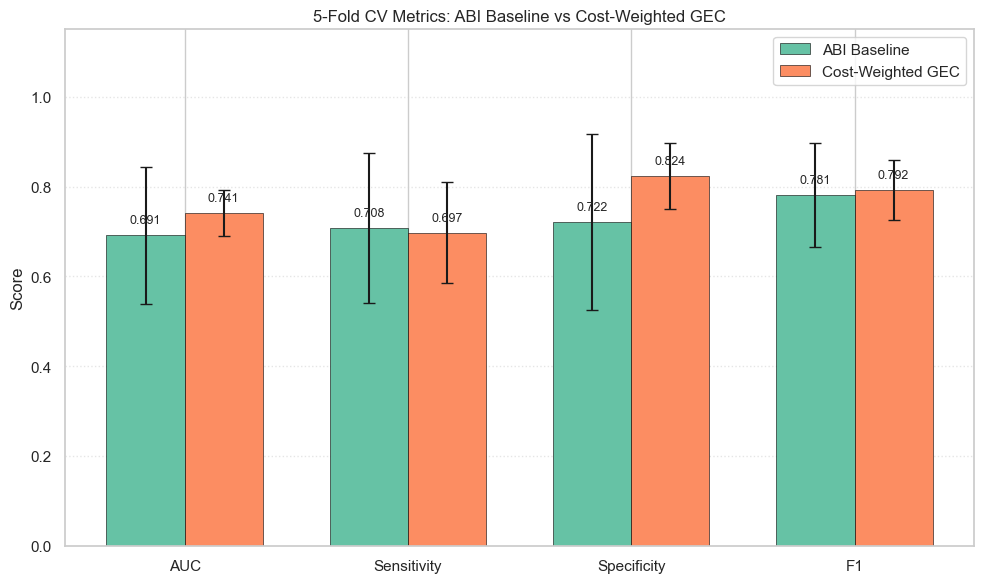

In [19]:
metrics = ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']
metric_labels = ['AUC', 'Sensitivity', 'Specificity', 'F1']

abi_means = [np.mean(abi_cv_results[m]) for m in metrics]
abi_stds = [np.std(abi_cv_results[m]) for m in metrics]
gec_means = [np.mean(gec_cv[m]) for m in metrics]
gec_stds = [np.std(gec_cv[m]) for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_abi = ax.bar(x - width / 2, abi_means, width, yerr=abi_stds, label='ABI Baseline',
                  color=sns.color_palette('Set2')[0], edgecolor='black', linewidth=0.4, capsize=4)
bars_gec = ax.bar(x + width / 2, gec_means, width, yerr=gec_stds, label='Cost-Weighted GEC',
                  color=sns.color_palette('Set2')[1], edgecolor='black', linewidth=0.4, capsize=4)

for bars in [bars_abi, bars_gec]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.0, h + 0.02, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score')
ax.set_title('5-Fold CV Metrics: ABI Baseline vs Cost-Weighted GEC')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

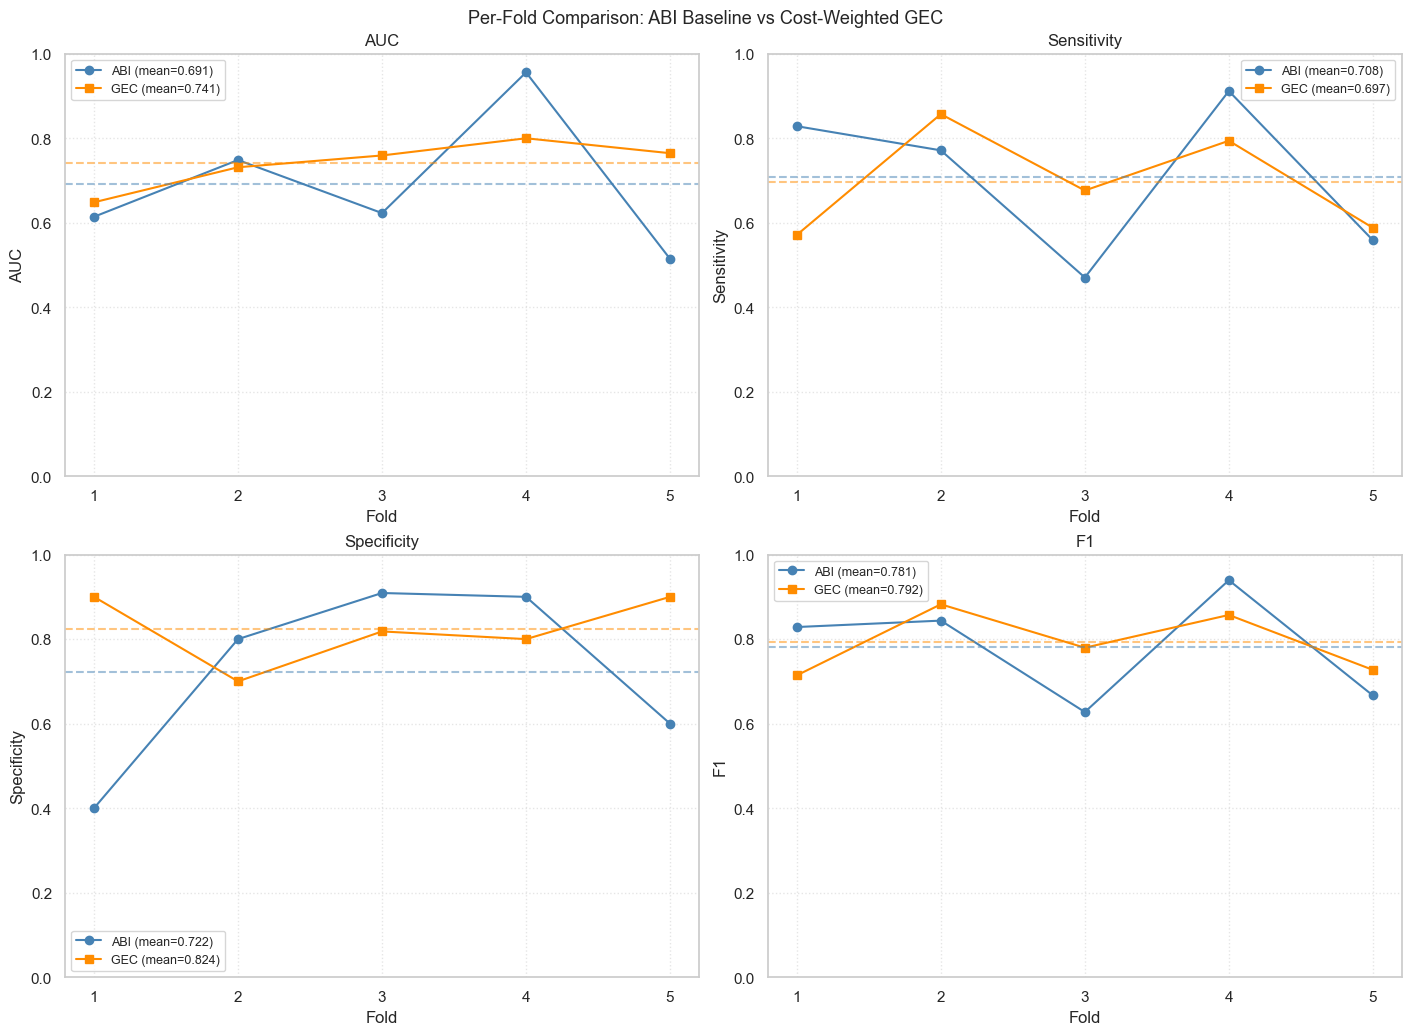

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

colors = sns.color_palette('colorblind', 4)

for ax, metric, label, color in zip(axes.flat, metrics, metric_labels, colors):
    abi_vals = np.array(abi_cv_results[metric], dtype=float)
    gec_vals = np.array(gec_cv[metric], dtype=float)
    folds = np.arange(1, N_FOLDS + 1)

    ax.plot(folds, abi_vals, 'o-', label=f'ABI (mean={abi_vals.mean():.3f})', color='steelblue', linewidth=1.5)
    ax.plot(folds, gec_vals, 's-', label=f'GEC (mean={gec_vals.mean():.3f})', color='darkorange', linewidth=1.5)
    ax.axhline(abi_vals.mean(), color='steelblue', linestyle='--', alpha=0.5)
    ax.axhline(gec_vals.mean(), color='darkorange', linestyle='--', alpha=0.5)
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(folds)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(linestyle=':', alpha=0.5)

fig.suptitle('Per-Fold Comparison: ABI Baseline vs Cost-Weighted GEC', fontsize=13, y=1.02)
plt.savefig(OUTPUT_DIR / 'cv_comparison_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()

## Holdout ROC Curve — ABI vs GEC (Superposed)

Both ABI and GEC holdout ROC curves are overlaid on the same plot. GEC holdout predictions are loaded from `holdout_predictions.json` in the selected GEC checkpoint directory. Both models use their CV-derived thresholds — no re-optimization on the test set.

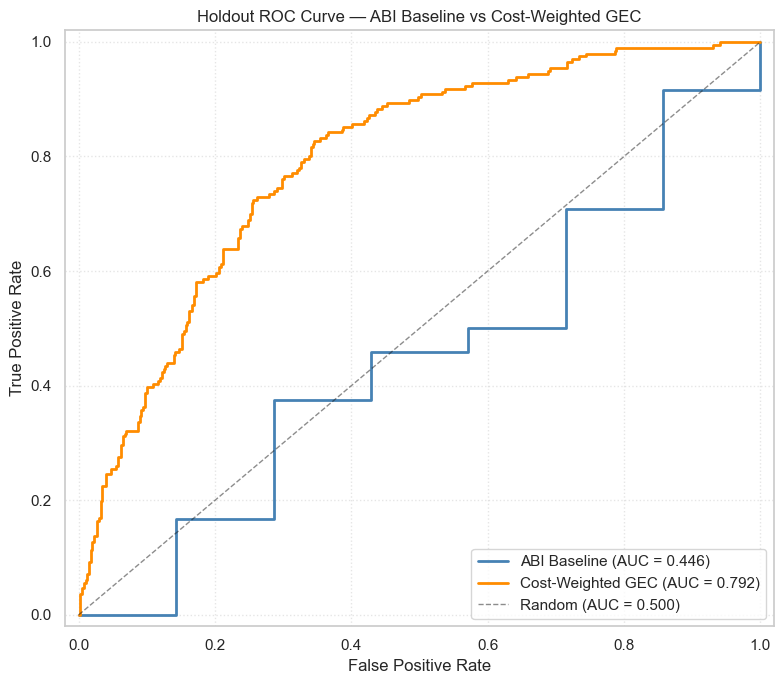

Holdout AUC (ABI Baseline): 0.4464
Holdout AUC (Cost-Weighted GEC): 0.7918

GEC Holdout Evaluation (CV threshold=0.9377):
  Sensitivity: 0.5153
  Specificity: 0.8383
  F1: 0.5580
  Confusion Matrix: TP=101, FP=65, FN=95, TN=337


In [21]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(fpr_h, tpr_h, color='steelblue', linewidth=2,
        label=f'ABI Baseline (AUC = {holdout_auc:.3f})')

if gec_holdout is not None:
    ax.plot(gec_holdout['fpr'], gec_holdout['tpr'], color='darkorange', linewidth=2,
            label=f'Cost-Weighted GEC (AUC = {gec_holdout["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Holdout ROC Curve — ABI Baseline vs Cost-Weighted GEC')
ax.legend(loc='lower right')
ax.grid(linestyle=':', alpha=0.5)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'holdout_roc_superposed.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Holdout AUC (ABI Baseline): {holdout_auc:.4f}')
if gec_holdout is not None:
    print(f'Holdout AUC (Cost-Weighted GEC): {gec_holdout["auc"]:.4f}')
    print(f'\nGEC Holdout Evaluation (CV threshold={gec_holdout["cv_threshold"]:.4f}):')
    print(f'  Sensitivity: {gec_holdout["sensitivity"]:.4f}')
    print(f'  Specificity: {gec_holdout["specificity"]:.4f}')
    print(f'  F1: {gec_holdout["f1"]:.4f}')
    cm = gec_holdout["confusion_matrix"]
    print(f'  Confusion Matrix: TP={cm["tp"]}, FP={cm["fp"]}, FN={cm["fn"]}, TN={cm["tn"]}')


## Save All Artifacts

In [22]:
run_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

comparison_results = {
    'run_timestamp': run_timestamp,
    'abi_run_dir': str(abi_run_dir),
    'abi_best_threshold': abi_best_threshold,
    'abi_cv_summary': abi_cv_summary,
    'gec_run_dir': str(gec_run_dir),
    'gec_cv_summary': gec_cv_summary,
    'holdout': {
        'abi': {
            'auc': float(holdout_auc),
            'sensitivity': float(holdout_sensitivity),
            'specificity': float(holdout_specificity),
            'f1': float(holdout_f1),
            'threshold': float(abi_best_threshold),
            'confusion_matrix': {'tp': int(tp_h), 'fp': int(fp_h), 'fn': int(fn_h), 'tn': int(tn_h)},
        },
        'gec': gec_holdout if gec_holdout is not None else None,
    },
}

with open(OUTPUT_DIR / 'abi_vs_gec_comparison.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)

print(f'Saved to: {OUTPUT_DIR}')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name}')

Saved to: /mnt/e/fyassine/ad-early-detection/DCI/notebooks/artifacts
  abi_baseline_results.json
  abi_distribution.png
  abi_values.csv
  abi_vs_gec_comparison.json
  cv_comparison.csv
  cv_comparison_bar.png
  cv_comparison_per_fold.png
  holdout_roc_abi.png
  holdout_roc_superposed.png
